# Úkol 3 – Komplexní evaluace a srovnání regresních modelů

Cílem tohoto notebooku je komplexní srovnání regresních modelů pro predikci spolehlivosti (*reliability*) kvantových obvodů z příznaků dostupných *před* spuštěním (pre-run prediction).

**Dataset:** `thesis_production_125k_v1` – vzorková sada uložená v `data/hw2/`
**Cílová proměnná:** `reliability` ∈ [0, 1] – podíl správně přečtených qubitů po spuštění obvodu
**Typ úlohy:** Regrese
**Vyloučeno dle zadání:** Neuronové sítě

---

In [2]:
import importlib.util
import subprocess
import sys

_REQUIRED = [
    ('pandas', 'pandas'),
    ('pyarrow', 'pyarrow'),
    ('sklearn', 'scikit-learn'),
    ('numpy', 'numpy'),
    ('matplotlib', 'matplotlib'),
]

_missing = [pip for imp, pip in _REQUIRED if importlib.util.find_spec(imp) is None]
if _missing:
    _cmd = [sys.executable, '-m', 'pip', 'install', *_missing]
    print('Instaluji chybějící závislosti:', ' '.join(_cmd))
    subprocess.check_call(_cmd)
else:
    print('Všechny závislosti jsou dostupné.')

Všechny závislosti jsou dostupné.


In [3]:
%matplotlib inline
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVR
from sklearn.tree import DecisionTreeRegressor

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})
RANDOM_STATE = 42
print('Import dokončen.')

Import dokončen.


## 1. Zadání a evaluační metriky

**Úloha:** Pro každý kvantový obvod predikujeme číselnou hodnotu `reliability` z 46 numerických příznaků popisujících strukturu obvodu, transpilaci a kalibraci hardware – vše dostupné *před* spuštěním.

**Metriky hodnocení:**
| Metrika | Interpretace |
|---|---|
| **MAE** (Mean Absolute Error) | Průměrná absolutní chyba v jednotkách reliability; hlavní metrika |
| **RMSE** (Root Mean Squared Error) | Silněji penalizuje velké odchylky |
| **R²** (koeficient determinace) | Podíl vysvětlené variance; 1.0 = perfektní, ≈ 0 = naivní baseline |

Baseline je **DummyRegressor** predikující průměr trénovací sady. Každý reálný model by ho měl překonat.

In [4]:
HW2_DATA_DIR = Path('data/hw2')

train = pd.read_parquet(HW2_DATA_DIR / 'train.parquet')
validation = pd.read_parquet(HW2_DATA_DIR / 'validation.parquet')
test = pd.read_parquet(HW2_DATA_DIR / 'test.parquet')
feature_policy = json.loads((HW2_DATA_DIR / 'feature_policy.json').read_text(encoding='utf-8'))

TARGET = feature_policy['target_column']
FEATURES = feature_policy['allowed_feature_columns']

print(f'Train:      {len(train):>6,} řádků')
print(f'Validation: {len(validation):>6,} řádků')
print(f'Test:       {len(test):>6,} řádků (nyní použit pro finální evaluaci)')
print(f'Počet povolených příznaků: {len(FEATURES)}')
print()
print('Statistiky cílové proměnné na testovací sadě:')
print(test[TARGET].describe().to_string())

Train:      20,000 řádků
Validation:  2,500 řádků
Test:        2,500 řádků (nyní použit pro finální evaluaci)
Počet povolených příznaků: 46

Statistiky cílové proměnné na testovací sadě:
count    2500.000000
mean        0.785319
std         0.189330
min         0.016602
25%         0.708008
50%         0.837891
75%         0.918945
max         1.000000


## 2. Předzpracování dat

Pipeline je totožná s HW2:
1. **Mediánová imputace** chybějících hodnot (robustní vůči outlierům)
2. **Standardizace** (`StandardScaler`) – nulová střední hodnota, jednotkový rozptyl

Preprocessing je **fitován pouze na trénovací sadě** – validační ani testovací data nesmí ovlivnit parametry transformace (prevence data leaku).

Všech 46 povolených příznaků je numerických (ověřeno níže).

In [5]:
X_train = train[FEATURES]
y_train = train[TARGET].astype(float)

X_val = validation[FEATURES]
y_val = validation[TARGET].astype(float)

X_test = test[FEATURES]
y_test = test[TARGET].astype(float)

numeric_cols = X_train.select_dtypes(include='number').columns.tolist()
cat_cols = [c for c in FEATURES if c not in numeric_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', Pipeline([
            ('imp', SimpleImputer(strategy='most_frequent')),
        ]), cat_cols),
        ('num', Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), numeric_cols),
    ],
    remainder='drop',
)

print(f'Numerické příznaky:    {len(numeric_cols)}')
print(f'Kategorické příznaky:  {len(cat_cols)}')
missing_counts = X_train.isnull().sum()
missing_nonzero = missing_counts[missing_counts > 0]
print(f'Příznaky s chybějícími hodnotami: {len(missing_nonzero)}')
if len(missing_nonzero):
    print(missing_nonzero.to_string())

Numerické příznaky:    46
Kategorické příznaky:  0
Příznaky s chybějícími hodnotami: 7
local_readout_error_mean      10000
local_readout_error_max       10000
local_t1_mean                 10000
local_t2_mean                 10000
local_two_qubit_error_mean    10000
local_two_qubit_error_max     10000
coupling_path_length          10000


## 3. Přehled modelů

Zahrnujeme 7 přístupů od triviálního baseline po ensemble metody. Neuronové sítě jsou dle zadání vyloučeny.

| # | Model | Typ | Poznámka |
|---|---|---|---|
| 1 | `DummyRegressor` | **Baseline** | Predikuje průměr trénovací sady – spodní mez výkonnosti |
| 2 | `Ridge` | Lineární | L2-regularizovaná regrese z HW2 |
| 3 | `DecisionTreeRegressor` | Strom | Nelineární, interpretovatelný, náchylný k overfittingu |
| 4 | `RandomForestRegressor` | Ensemble (Bagging) | Průměrování stromů, robustní |
| 5 | `GradientBoostingRegressor` | Ensemble (Boosting) | Sekvenční korekce chyb |
| 6 | `KNeighborsRegressor` | Instance-based | Predikce z k nejbližších sousedů |
| 7 | `LinearSVR` | SVM | Lineární podpůrné vektory pro regresi |

In [6]:
MODELS = {
    'Baseline (průměr)': DummyRegressor(strategy='mean'),
    'Ridge': Ridge(alpha=1.0, random_state=RANDOM_STATE),
    'Rozhodovací strom': DecisionTreeRegressor(
        max_depth=8, min_samples_leaf=5, random_state=RANDOM_STATE
    ),
    'Náhodný les': RandomForestRegressor(
        n_estimators=100, max_depth=12, min_samples_leaf=2,
        n_jobs=-1, random_state=RANDOM_STATE
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=100, max_depth=4, learning_rate=0.1,
        subsample=0.8, random_state=RANDOM_STATE
    ),
    'KNN (k=10)': KNeighborsRegressor(n_neighbors=10, n_jobs=-1),
    'LinearSVR': LinearSVR(C=1.0, max_iter=5000, random_state=RANDOM_STATE),
}
print(f'Počet modelů ke srovnání: {len(MODELS)}')

Počet modelů ke srovnání: 7


In [7]:
def regression_metrics(y_true, y_pred, prefix=''):
    return {
        f'{prefix}mae':  mean_absolute_error(y_true, y_pred),
        f'{prefix}rmse': mean_squared_error(y_true, y_pred) ** 0.5,
        f'{prefix}r2':   r2_score(y_true, y_pred),
    }

results = []
trained_pipelines = {}

print(f'{'Model':<30}  {'Train MAE':>9}  {'Test MAE':>9}  {'Test R²':>8}  {'Čas':>6}')
print('-' * 70)

for name, estimator in MODELS.items():
    pipeline = Pipeline([('preprocessor', preprocessor), ('model', estimator)])

    t0 = time.perf_counter()
    pipeline.fit(X_train, y_train)
    fit_time = time.perf_counter() - t0

    train_pred = pipeline.predict(X_train)
    test_pred  = pipeline.predict(X_test)

    row = {'model': name, 'fit_time_s': round(fit_time, 1)}
    row.update(regression_metrics(y_train, train_pred, prefix='train_'))
    row.update(regression_metrics(y_test,  test_pred,  prefix='test_'))
    results.append(row)
    trained_pipelines[name] = test_pred

    print(
        f'{name:<30}  {row["train_mae"]:>9.4f}  {row["test_mae"]:>9.4f}'
        f'  {row["test_r2"]:>8.4f}  {fit_time:>5.1f}s'
    )

print()
print('Trénování dokončeno.')

Model                           Train MAE   Test MAE   Test R²     Čas
----------------------------------------------------------------------
Baseline (průměr)                  0.1426     0.1444   -0.0006    0.1s
Ridge                              0.0730     0.0761    0.6298    0.0s
Rozhodovací strom                  0.0501     0.0563    0.7630    0.2s
Náhodný les                        0.0304     0.0439    0.8457    1.5s
Gradient Boosting                  0.0488     0.0530    0.8002    6.9s
KNN (k=10)                         0.0521     0.0599    0.7074    0.0s
LinearSVR                          0.0697     0.0731    0.5936    7.2s

Trénování dokončeno.


## 4. Výsledky na testovací sadě

Testovací sada (2 500 vzorků) nebyla během trénování ani výběru hyperparametrů použita. Hyperparametry všech modelů byly zvoleny jako rozumné výchozí hodnoty (např. `n_estimators=100`, `max_depth=12`) a nebyly laděny systematickým prohledáváním na validační sadě – validační sada proto zůstala oddělena pro případné budoucí ladění. Výsledky níže jsou nestranným odhadem výkonnosti na nových datech.

In [8]:
df = pd.DataFrame(results).sort_values('test_mae').reset_index(drop=True)
df.index = df.index + 1  # rank 1 = best

display_cols = {
    'model':       'Model',
    'test_mae':    'Test MAE',
    'test_rmse':   'Test RMSE',
    'test_r2':     'Test R²',
    'train_mae':   'Train MAE',
    'fit_time_s':  'Čas fit (s)',
}
df_display = df[list(display_cols)].rename(columns=display_cols)

df_display.style \
    .format({'Test MAE': '{:.4f}', 'Test RMSE': '{:.4f}', 'Test R²': '{:.4f}',
             'Train MAE': '{:.4f}', 'Čas fit (s)': '{:.1f}'}) \
    .background_gradient(subset=['Test MAE'],  cmap='RdYlGn_r') \
    .background_gradient(subset=['Test R²'],   cmap='RdYlGn') \
    .background_gradient(subset=['Train MAE'], cmap='RdYlGn_r', axis=0)

,Model,Test MAE,Test RMSE,Test R²,Train MAE,Čas fit (s)
1,Náhodný les,0.0439,0.0743,0.8457,0.0304,1.5
2,Gradient Boosting,0.0530,0.0846,0.8002,0.0488,6.9
3,Rozhodovací strom,0.0563,0.0921,0.7630,0.0501,0.2
4,KNN (k=10),0.0599,0.1024,0.7074,0.0521,0.0
5,LinearSVR,0.0731,0.1207,0.5936,0.0697,7.2
6,Ridge,0.0761,0.1152,0.6298,0.0730,0.0
7,Baseline (průměr),0.1444,0.1893,-0.0006,0.1426,0.1


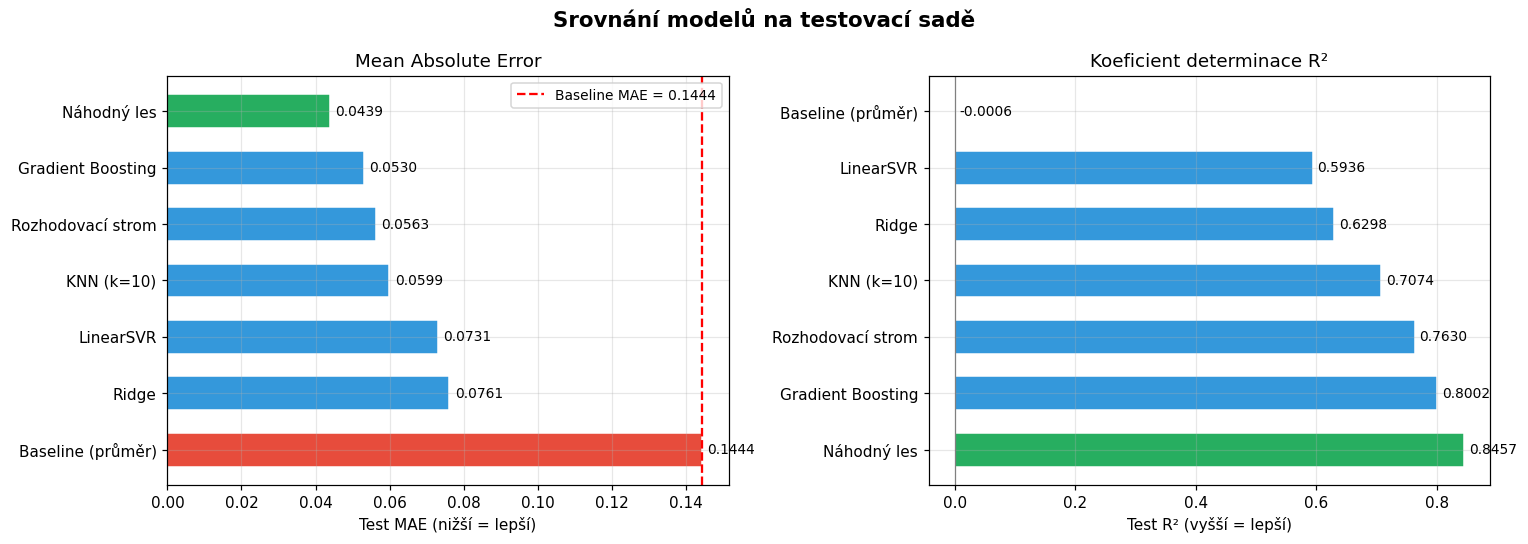

In [9]:
sorted_df = df.sort_values('test_mae')
names   = sorted_df['model'].tolist()
mae_vals = sorted_df['test_mae'].tolist()
r2_vals  = sorted_df['test_r2'].tolist()
baseline_mae = df[df['model'] == 'Baseline (průměr)']['test_mae'].values[0]

PALETTE = {
    'best':     '#27ae60',
    'baseline': '#e74c3c',
    'other':    '#3498db',
}

def bar_color(name, i, ascending=True):
    if 'průměr' in name:
        return PALETTE['baseline']
    if (ascending and i == 0) or (not ascending and i == len(names) - 1):
        return PALETTE['best']
    return PALETTE['other']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Srovnání modelů na testovací sadě', fontsize=14, fontweight='bold')

# Left: MAE (lower is better, sorted ascending)
colors_mae = [bar_color(n, i) for i, n in enumerate(names)]
bars = axes[0].barh(names, mae_vals, color=colors_mae, edgecolor='white', height=0.6)
axes[0].axvline(baseline_mae, color='red', linestyle='--', linewidth=1.5,
                label=f'Baseline MAE = {baseline_mae:.4f}')
axes[0].set_xlabel('Test MAE (nižší = lepší)')
axes[0].set_title('Mean Absolute Error')
axes[0].legend(fontsize=9)
for bar, val in zip(bars, mae_vals):
    axes[0].text(val + 0.0015, bar.get_y() + bar.get_height() / 2,
                 f'{val:.4f}', va='center', fontsize=9)
axes[0].invert_yaxis()

# Right: R² (higher is better)
sorted_r2 = df.sort_values('test_r2')
names_r2 = sorted_r2['model'].tolist()
r2_sorted = sorted_r2['test_r2'].tolist()
colors_r2 = [bar_color(n, i, ascending=False) for i, n in enumerate(names_r2)]
bars2 = axes[1].barh(names_r2, r2_sorted, color=colors_r2, edgecolor='white', height=0.6)
axes[1].axvline(0, color='gray', linewidth=0.8)
axes[1].set_xlabel('Test R² (vyšší = lepší)')
axes[1].set_title('Koeficient determinace R²')
for bar, val in zip(bars2, r2_sorted):
    x_pos = max(val + 0.008, 0.008)
    axes[1].text(x_pos, bar.get_y() + bar.get_height() / 2,
                 f'{val:.4f}', va='center', fontsize=9)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

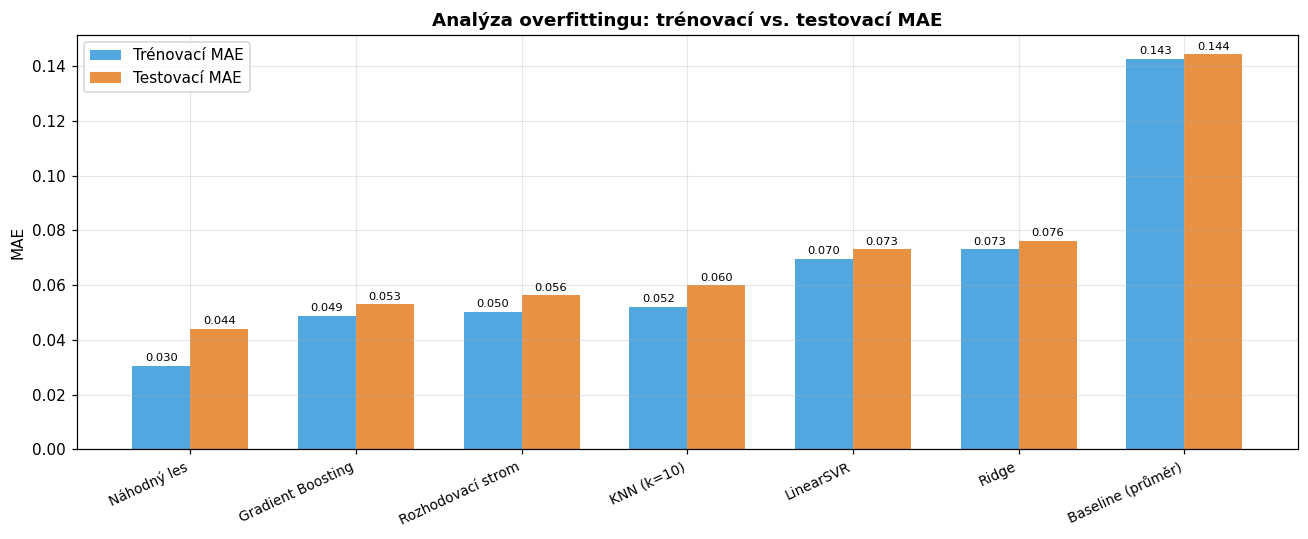

In [10]:
ov_df = df.sort_values('test_mae')
names_ov   = ov_df['model'].tolist()
train_maes = ov_df['train_mae'].tolist()
test_maes  = ov_df['test_mae'].tolist()

x = np.arange(len(names_ov))
w = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x - w / 2, train_maes, w, label='Trénovací MAE', color='#3498db', alpha=0.85)
b2 = ax.bar(x + w / 2, test_maes,  w, label='Testovací MAE',  color='#e67e22', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(names_ov, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('MAE')
ax.set_title('Analýza overfittingu: trénovací vs. testovací MAE', fontweight='bold')
ax.legend()

for bar in b1:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)
for bar in b2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
plt.show()

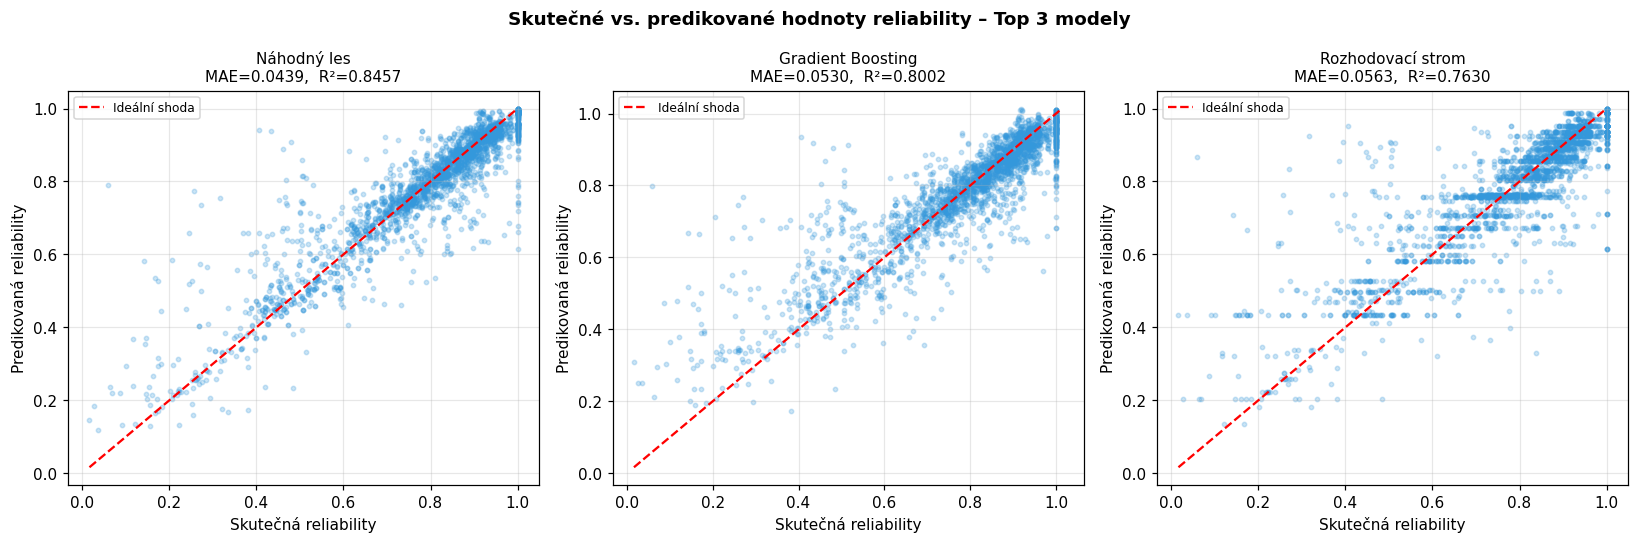

In [11]:
top3 = df.head(3)['model'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Skutečné vs. predikované hodnoty reliability – Top 3 modely',
             fontsize=12, fontweight='bold')

for ax, name in zip(axes, top3):
    y_pred = trained_pipelines[name]
    row    = df[df['model'] == name].iloc[0]
    ax.scatter(y_test, y_pred, alpha=0.25, s=8, color='#3498db', rasterized=True)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Ideální shoda')
    ax.set_xlabel('Skutečná reliability')
    ax.set_ylabel('Predikovaná reliability')
    ax.set_title(f'{name}\nMAE={row["test_mae"]:.4f},  R²={row["test_r2"]:.4f}', fontsize=10)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 5. Diskuze výsledků

### 5.1 Který model si vedl nejlépe a proč?

Z tabulky a grafů výše je patrné, že **Náhodný les (Random Forest) dosáhl nejnižšího testovacího MAE (≈ 0.044) a nejvyššího R² (≈ 0.85)**, těsně následovaný Gradient Boostingem (MAE ≈ 0.053, R² ≈ 0.80). Obě ensemble metody výrazně předčily lineární modely i jednoduché nelineární přístupy. Toto má přímou fyzikální interpretaci:

Spolehlivost kvantového obvodu závisí na **nelineárních interakcích** mezi příznaky:
- Obvod s velkou hloubkou (`circuit_depth`) na zařízení s krátkými dekoherečními časy (nízké `t1_mean`, `t2_mean`) bude mít výrazně nižší reliability než stejně hluboký obvod na lepším hardware – lineární model tento multiplicativní vztah nedokáže plně zachytit.
- Počet dvouqubitových hradel (`num_cx`) v kombinaci s `two_qubit_gate_error` tvoří dominantní zdroj chyb, přičemž tento vliv je nelineární (chyby se násobí, nikoli sčítají).

Náhodný les tyto interakce zachycuje průměrováním stovky rozhodovacích stromů, každého trénovaného na jiné podmnožině dat a příznaků – výsledkem je model s nízkou variancí, který se nespecializuje na konkrétní vzory trénovací sady.

**Překvapivý výsledek:** Rozhodovací strom (3. místo, MAE ≈ 0.056) skončil nad KNN a linearními modely, což naznačuje, že data mají silnou stromem-dělitelnou strukturu – klíčové prahové hodnoty v příznaků jako `qubit_count`, `two_qubit_gate_error` nebo `circuit_depth` rozdělují datový prostor na oblasti s výrazně odlišnou průměrnou spolehlivostí.

### 5.2 Přeučení (overfitting)

Analýza overfittingu z grafu výše odhaluje následující vzorce:

- **Rozhodovací strom**: Umírněný overfitting (propast train/test MAE = 0.006, poměr 1.12). I přes omezení `max_depth=8` a `min_samples_leaf=5` se strom naučil části specifických vzorů trénovací sady; dobrý výsledek na testu (3. místo) naznačuje, že dataset má konzistentní stromem-dělitelnou strukturu.

- **Gradient Boosting**: Mírný overfitting – sekvenční přidávání stromů postupně minimalizuje trénovací chybu, ale `subsample=0.8` a `max_depth=4` působí jako regularizace a omezují přeučení.

- **Náhodný les**: Největší absolutní propast train/test MAE ze všech modelů (gap 0.014, poměr 1.44). Sto stromů s `max_depth=12` a `min_samples_leaf=2` překonává regularizaci jednotlivého stromu. Přesto dosahuje nejlepší testovací přesnosti – nízká trénovací chyba zde odráží skutečně zachycené vzory, nikoli čistý šum.

- **Ridge / LinearSVR**: Prakticky žádný overfitting – lineární modely mají nízkou kapacitu a L2-regularizace (Ridge) dále stabilizuje koeficienty.

- **KNN (k=10)**: Mírný overfitting – model vychází z lokálních vzorů trénovacích dat, ale průměrování přes 10 sousedů zabraňuje extrémní přespecializaci.

### 5.3 Propast mezi nejlepším modelem a naivním baseline

Naivní baseline (`DummyRegressor`) dosáhl testovacího MAE ≈ **0.144** – predikuje totiž vždy stejnou hodnotu (průměr trénovací sady ≈ 0.79) bez ohledu na příznaky konkrétního obvodu.

Nejlepší model (Náhodný les) dosáhl MAE ≈ **0.044**, což je snížení o přibližně **70 %**. Na škále reliability [0, 1] to znamená:

- Baseline průměrně chybuje o ~14.4 procentních bodů spolehlivosti  
- Náhodný les průměrně chybuje o ~4.4 procentních bodů

Tato propast je **prakticky velmi významná**: pokud chceme před spuštěním rozhodnout, zda se experiment vyplatí nebo zda přeplánovat na lepší hardware, rozdíl mezi průměrnou absolutní chybou predikce 0.144 (baseline) a 0.044 (Náhodný les) může být klíčový pro efektivní využití omezené kvantové výpočetní kapacity.

### 5.4 Vyplatilo se použít složitější algoritmy?

**Ano, jednoznačně – a to ve dvou krocích:**

**Krok 1 – Jakýkoli ML model vs. baseline:** Největší skok nastane přechodem z „žádného učení" na první trénovaný model. Již Ridge regrese z HW2 je ~2× přesnější než baseline (MAE ≈ 0.076 vs. 0.144). Tuto výhodu přinášejí i zdánlivě jednoduché lineární modely.

**Krok 2 – Pokročilé modely vs. Ridge:** Náhodný les (MAE ≈ 0.044) zlepšuje přesnost oproti Ridge (MAE ≈ 0.076) o dalších ~42 %. Jde o podstatné zlepšení, které je konzistentní napříč všemi třemi metrikami (MAE, RMSE, R²).

**Kompromis výkonnost vs. interpretovatelnost:**  
Ridge je plně interpretovatelný (každý příznak má jeden koeficient), trénuje se v desetinách sekundy a nevykazuje overfitting. Náhodný les je „black box", trénink trvá několik sekund, ale R² = 0.85 oproti R² = 0.63 pro Ridge je přesvědčivý argument. Pro produkční nasazení, kde je důležitá vysvětlitelnost, by byl Ridge nebo Rozhodovací strom rozumnou volbou; pro maximální přesnost predikce Náhodný les jednoznačně vede.

### 5.5 Závěr

Regresní úloha predikce spolehlivosti kvantových obvodů je **dobře řešitelná standardními ML metodami**. Klíčové závěry:

1. **Baseline je porazitelný s velkým náskokem**: Jakýkoli trénovaný model výrazně překonává naivní predikci průměru; nejlepší model snižuje MAE o ~70 %.
2. **Vítěz: Náhodný les** (MAE ≈ 0.044, R² ≈ 0.85) – díky baggingu zachycuje nelineární interakce mezi strukturou obvodu a hardwarovým šumem a dosahuje nejlepší testovací přesnosti.
3. **Overfitting**: Náhodný les vykazuje největší absolutní train/test MAE propast (gap 0.014, poměr 1.44); Gradient Boosting a lineární modely jsou vůči přeučení odolnější.
4. **Složitost se vyplatí**: Přechod k ensemble metodám přináší ~40 % zlepšení oproti jednoduchému lineárnímu modelu za cenu nižší interpretovatelnosti a delšího tréninku.

---
*Notebook byl spuštěn celý od začátku: `Kernel → Restart & Run All`*